## False discovery rate (FDR) correction

 + Implementation of FDR correction using an empirical null distribution and Benjamini Hochberg (BH) method
 + Implementation of FDR correction using an empirical null distribution and Storey's Q-Value method

*Note: An initial transformation of names from parcel names to region of interest names are given here. Please note, these are not the end names found on the paper's figures. Those are given in `classification_04_figures.ipynb` and are extracted from the tools FSLeyes and fMRICRO using the ROIs MNI152 coordinates.*

*Note: Prediction of visit 4 from visit 1 data, and visit 4 from visit 1,2,3 are performed in `classification_01` and saved in CSV. That needs to be run before this notebook can be run.* 
    

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import scipy.stats as stats
from scipy.stats import zscore
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from brainrender import Scene
import nibabel as nib
import ptitprince as pt
import re
import ast
import os
import ast

from parcellation_to_classification_utils import *
from fdr_correction_functions import *

#PLease change according to your machine
user = "gaia"

embedWindow(verbose=True): could not load ipyvtklink try:
> pip install ipyvtklink


In [2]:
#Retrieve paths used for analysis, path is based on user 
base_path, tian_atlas_path, tian_label_path, z_map_path, second_level_glm_path, run_mapping = obtain_base_paths(user)

# Load the Schaefer atlas (assuming get_schaefer_parcellation is defined)
schaefer_img, schaefer_labels = get_schaefer_parcellation(n_rois=200)

# Load the Tian atlas (assuming get_tian_parcellation is defined)
tian_img, tian_labels = get_tian_parcellation(tian_atlas_path, tian_label_path)

# Combine the atlases (assuming combine_parcellations is defined)
combined_img, combined_labels = combine_parcellations(schaefer_img, tian_img, schaefer_labels, tian_labels)

### FDR CORRECTION PIPELINE

### Storey's q-value

#### Importing csv files containing the significant parcels after permutation test results

In [3]:
gbm_significant_parcels = pd.read_csv("Results/Intermediate_Files/fMRI_Classifiers_Significant_Output/GradientBoostingClassifier/gbm_significant_parcels_df")

svc_significant_parcels = pd.read_csv("Results/Intermediate_Files/fMRI_Classifiers_Significant_Output/SVC/svc_significant_parcels_df")

gbm_early_significant_parcels = pd.read_csv("Results/Intermediate_Files/fMRI_Classifiers_Significant_Output/GradientBoostingClassifier/early_prediction_gbm_significant_parcels_df")

svc_early_significant_parcels = pd.read_csv("Results/Intermediate_Files/fMRI_Classifiers_Significant_Output/SVC/early_prediction_svc_significant_parcels_df")

### GBM - all visits case

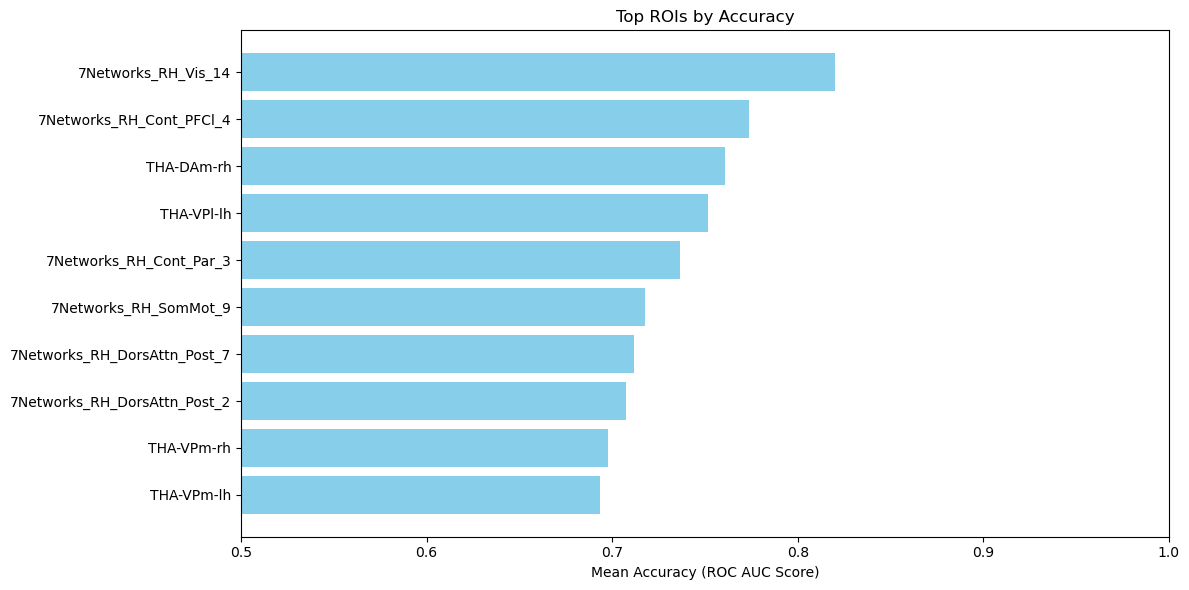

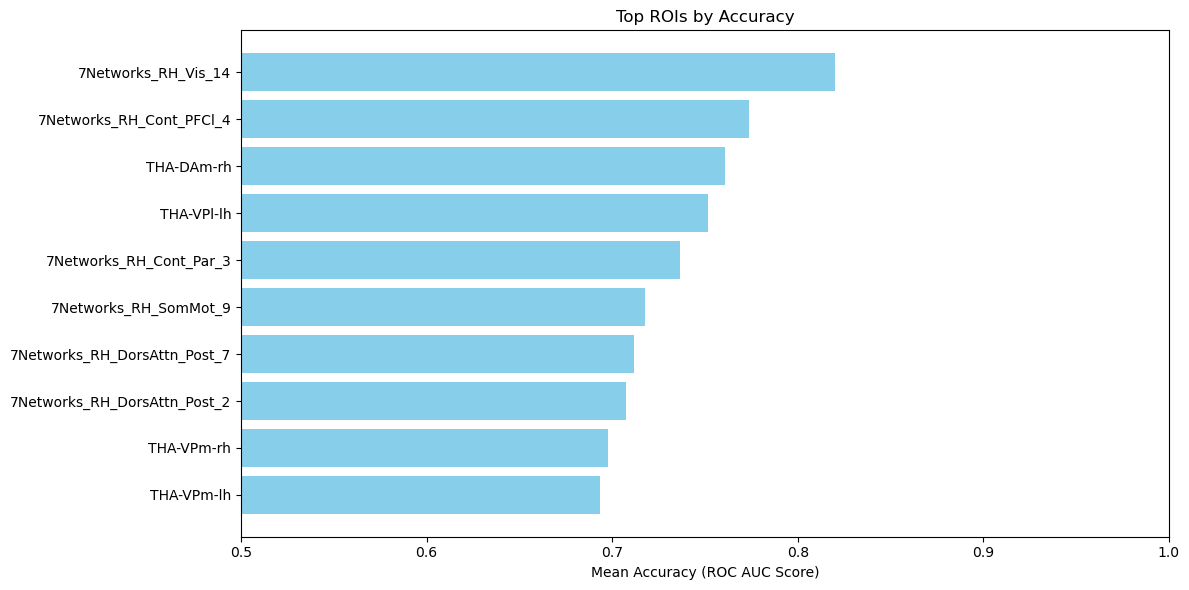

In [4]:
#Gradient Boost 

gbm_bh_significant = benjamini_hochberg(gbm_significant_parcels, model="GBM", prediction ="all_visits")
gbm_storey_significant = storey_q_value(gbm_significant_parcels, model = "GBM", prediction="all_visits")

In [ ]:
#Apply an initial screening to get anatomical names
gbm_bh_significant_copy = gbm_significant_parcels.copy()
gbm_bh_significant = parcel_to_network_name(gbm_bh_significant_copy)

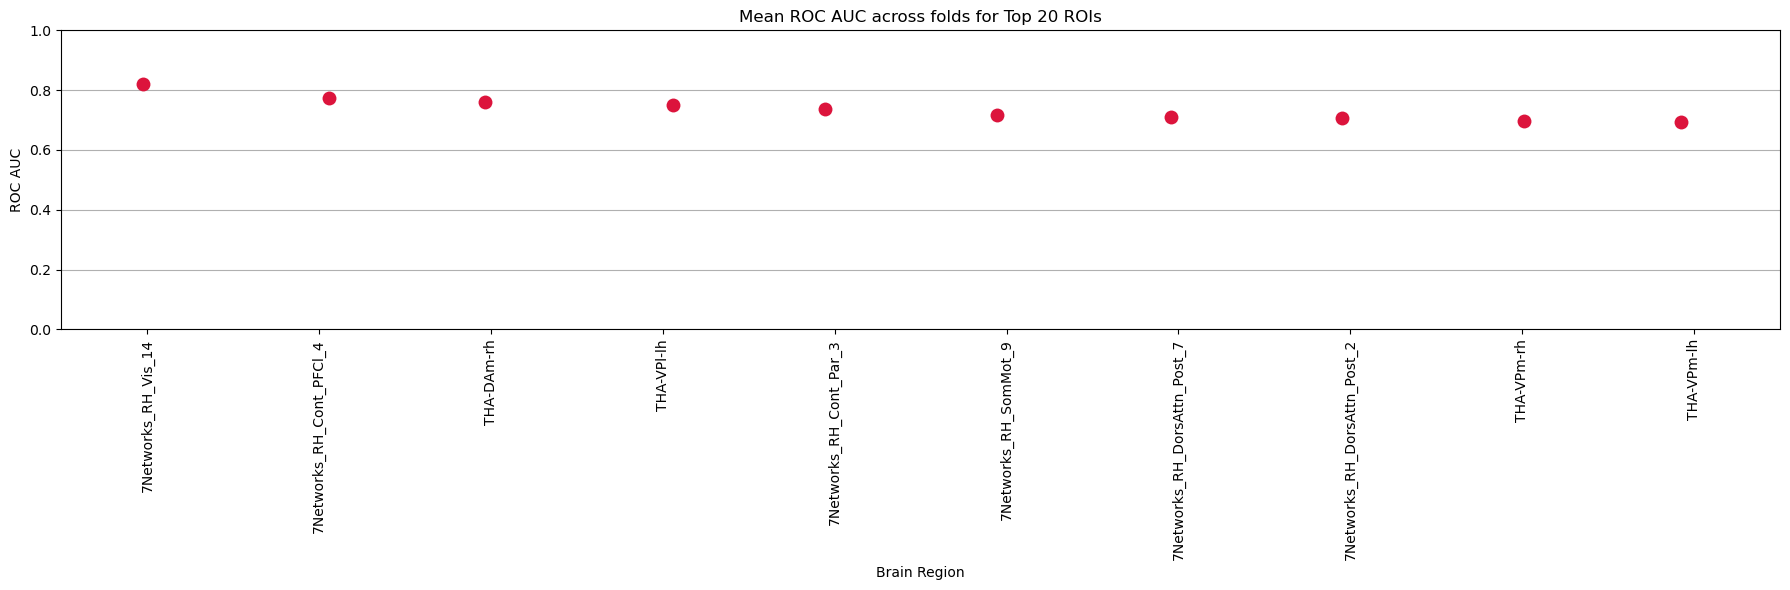

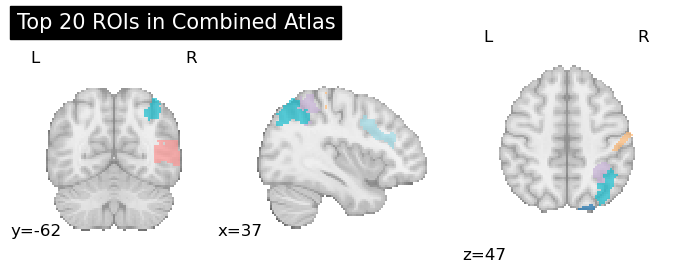

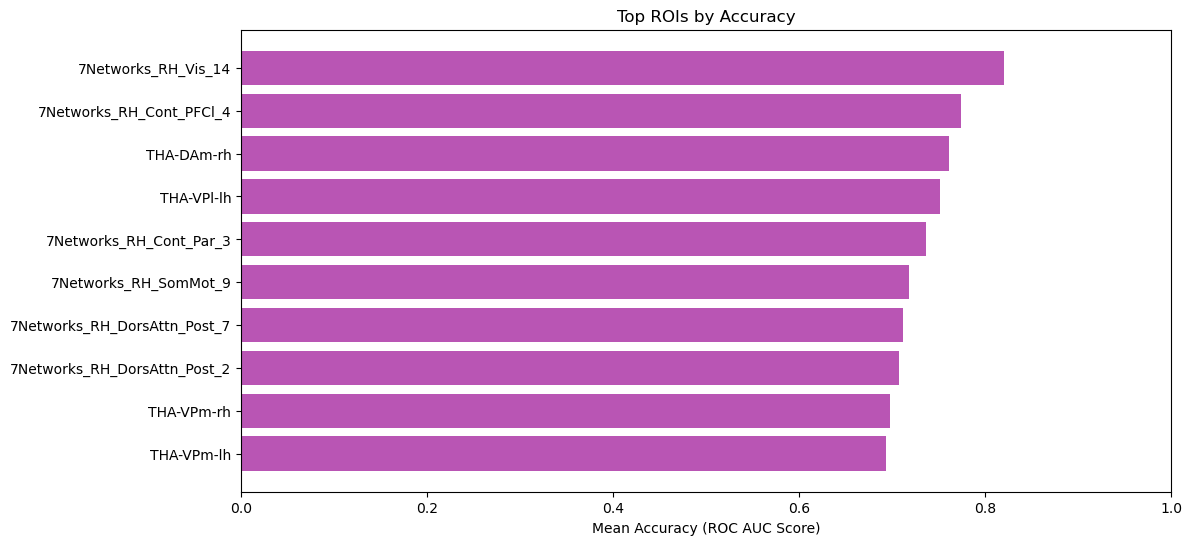

In [8]:
#number of top parcels to consider
nr_top_parcels = 20

# --- Visualise violin plots of mean performance per iteration, top 20 combined atlas glass, and top5 glass brain
visualize_top_rois_from_performance_df(gbm_bh_significant, base_path, combined_labels, combined_img, top_n=nr_top_parcels,
                                       save_nifti = False)

# -- Display the average confusion matrix (across n iterations, each y folds) per top 20 parcels
# confusion_matrix_per_fold(gbm_top_parcels)

barplot_top_ROIs(gbm_bh_significant, nr_top_parcels)

### SVC - all visits 

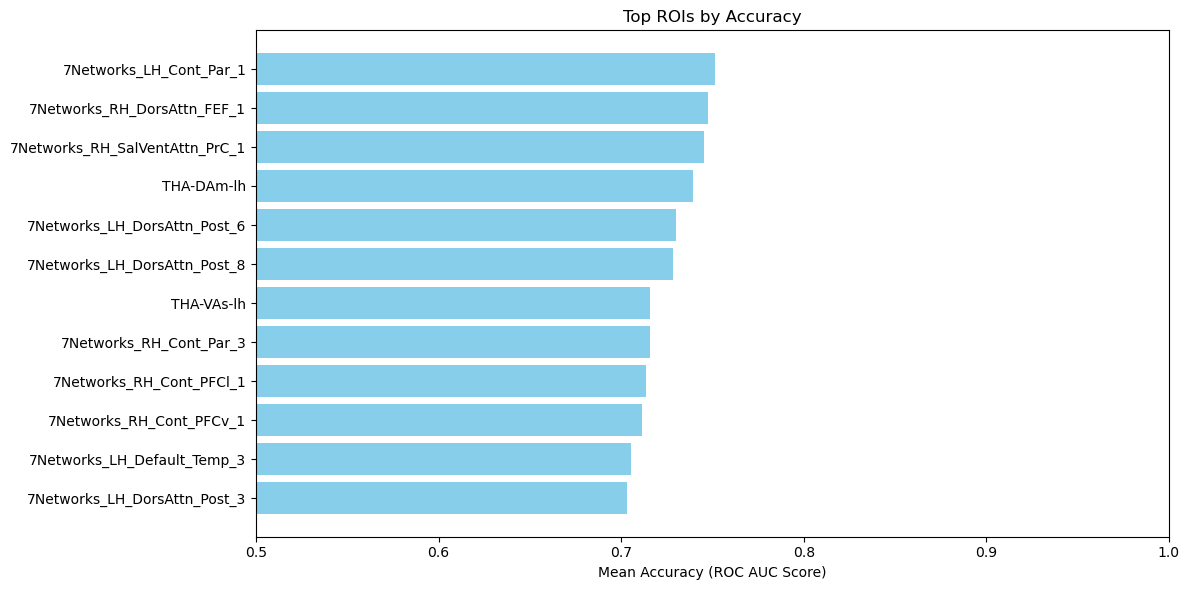

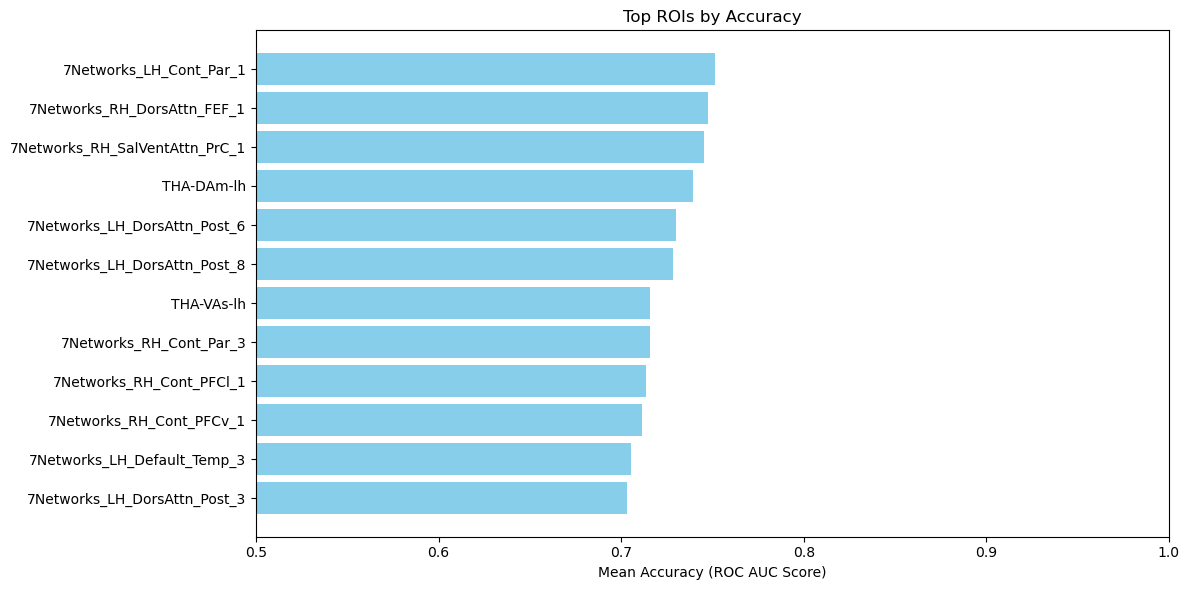

In [9]:
#SVC

svc_bh_significant = benjamini_hochberg(svc_significant_parcels, model="SVC", prediction ="all_visits")

svc_storey_significant = storey_q_value(svc_significant_parcels, model="SVC", prediction ="all_visits")

In [10]:
svc_bh_significant_copy = svc_significant_parcels.copy()
svc_bh_significant = parcel_to_network_name(svc_bh_significant_copy)

### GBM - visits 1 and 4

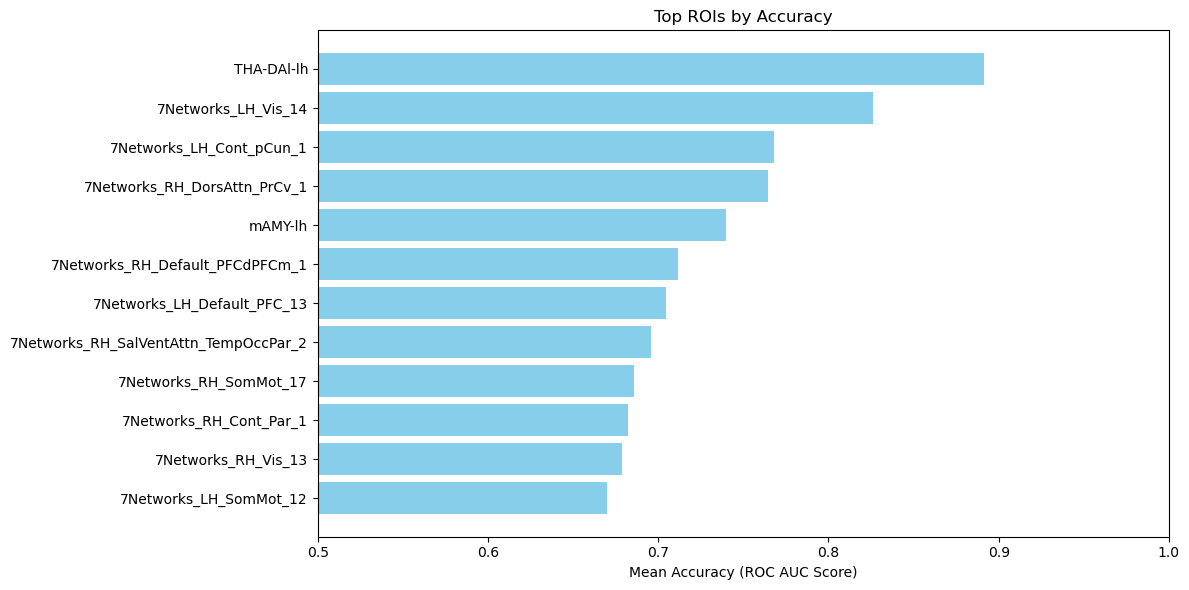

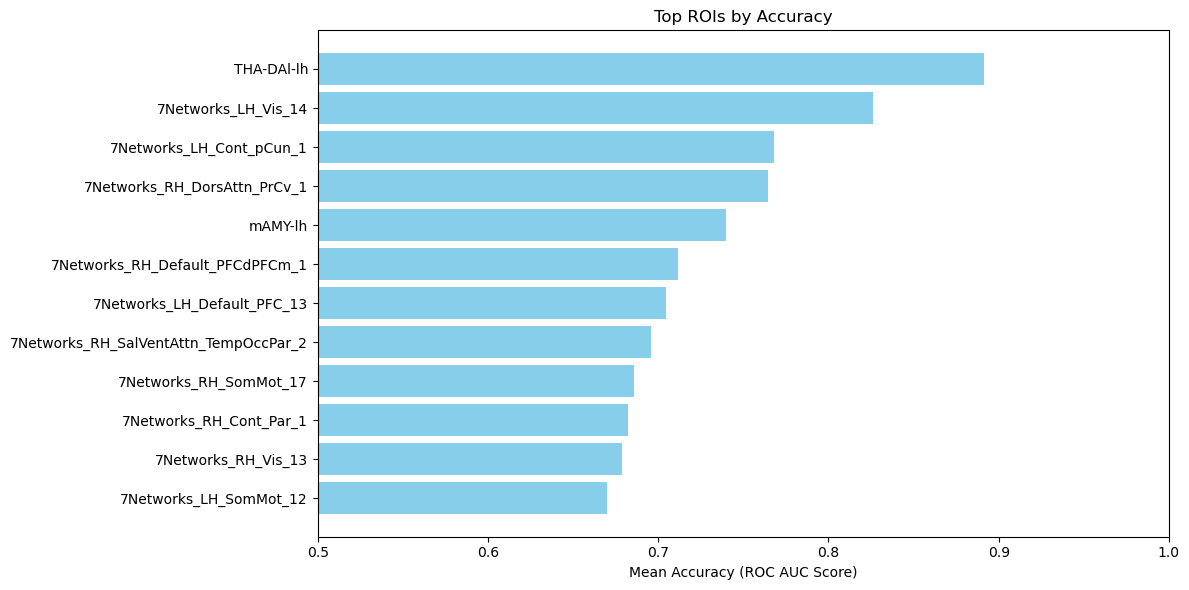

In [11]:
early_gbm_bh_significant = benjamini_hochberg(gbm_early_significant_parcels, model="GBM", prediction ="early_pred")

early_gbm_storey_significant = storey_q_value(gbm_early_significant_parcels, model="GBM", prediction ="early_pred")

In [12]:
early_gbm_bh_significant_copy = early_gbm_bh_significant.copy()
early_gbm_bh_significant = parcel_to_network_name(early_gbm_bh_significant_copy)

### SVC - visit 1 predicts visit 4

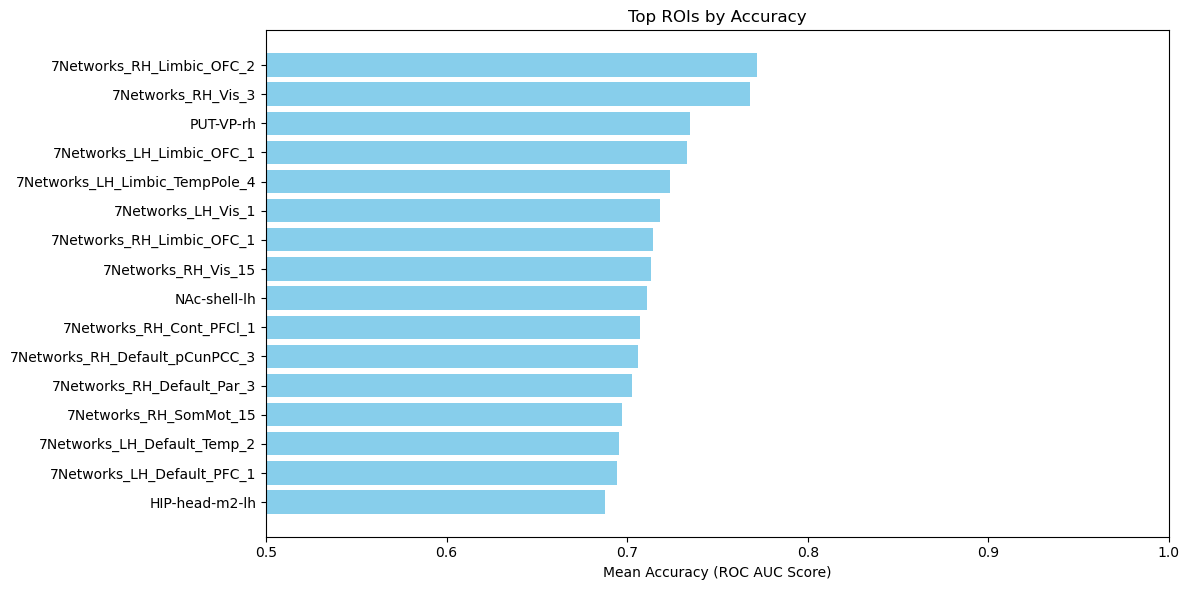

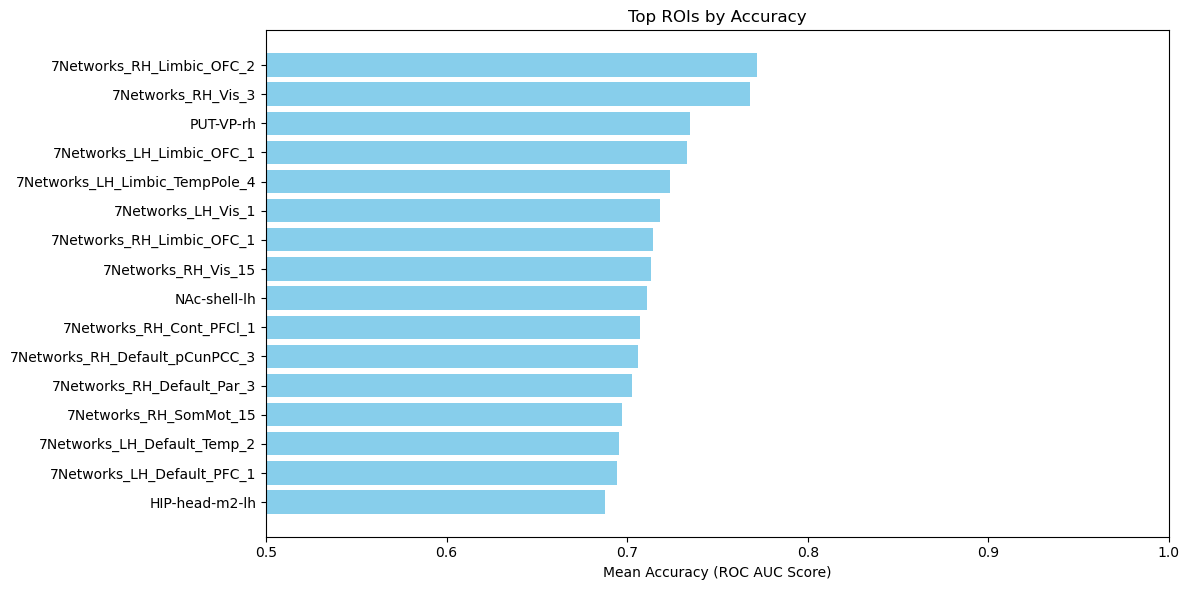

In [13]:
early_svc_bh_significant = benjamini_hochberg(svc_early_significant_parcels, model="SVC", prediction ="early_pred")

early_svc_storey_significant = storey_q_value(svc_early_significant_parcels, model="SVC", prediction ="early_pred")

In [14]:
early_svc_bh_significant_copy = early_svc_bh_significant.copy()
early_svc_bh_significant = parcel_to_network_name(early_svc_bh_significant_copy)

### Save CSVs

In [15]:
#Save all dataframes as CSVs to produce figures in Gaia_05_Figures
GBM_save_path = os.path.join("Results", "Intermediate_Files", "FDR_corrected_fMRI_Classifier_Output",
                          "GradientBoostingClassifier")

SVC_save_path = os.path.join("Results", "Intermediate_Files", "FDR_corrected_fMRI_Classifier_Output",
                          "SVC")


gbm_bh_significant.to_csv(os.path.join(GBM_save_path, "gbm_bh_all_visits_FDRcorrected"), index=False)
early_gbm_bh_significant.to_csv(os.path.join(GBM_save_path, "gbm_bh_early_pred_FDRcorrected"), index=False)

svc_bh_significant.to_csv(os.path.join(SVC_save_path, "svc_bh_all_visits_FDRcorrected"), index=False)
early_svc_bh_significant.to_csv(os.path.join(SVC_save_path, "svc_bh_early_pred_FDRcorrected"), index=False)